# TEAM 17: Deepfake Detection with OpenCLIP + LoRA + PyTorch Lightning

Model: `laion2b_s34b_b82k_augreg_soup` (ConvNext XXLarge)

Technique: PEFT LoRA on Backbone

Framework: PyTorch Lightning

Dataset: 15k Train (Fake/Real), 7k Test (Fake/Real)

Task: Binary Classification (Real vs Fake)

Designed by 314511063

In [1]:
!pip install -q -r requirements.txt

In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import open_clip
import pytorch_lightning as pl
from peft import LoraConfig, get_peft_model
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import sigmoid_focal_loss
from sklearn.model_selection import train_test_split
from pytorch_lightning.callbacks import ModelCheckpoint

# Config
MODEL_NAME = 'hf-hub:laion/CLIP-convnext_xxlarge-laion2B-s34B-b82K-augreg-soup'
BATCH_SIZE = 8
GRAD_ACCUM = 2  # Effective Batch Size = 16
EPOCHS = 5
LR = 1e-4
SEED = 42
LORA_R = 16
LORA_ALPHA = 16
LORA_TARGET_MODULES = ["fc1", "fc2"]
LORA_DROPOUT = 0.1
USE_DORA=False


pl.seed_everything(SEED)

/home/auroral/miniconda3/envs/team17/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42


42

In [3]:
# Paths
DATASET_DIR = Path("./dataset")
TRAIN_REAL_DIR = DATASET_DIR / "train" / "real"
TRAIN_FAKE_DIR = DATASET_DIR / "train" / "fake"
TEST_DIR = DATASET_DIR / "test"

# Collect Files
train_real_paths = sorted(list(TRAIN_REAL_DIR.glob("*.jpg")))
train_fake_paths = sorted(list(TRAIN_FAKE_DIR.glob("*.jpg")))
test_paths = sorted(list(TEST_DIR.glob("*.jpg")), key=lambda p: int(p.stem))

print(f"Train Real: {len(train_real_paths)}")
print(f"Train Fake: {len(train_fake_paths)}")
print(f"Test: {len(test_paths)}")

# Labels: 0 for Real, 1 for Fake
all_paths = train_real_paths + train_fake_paths
all_labels = [0.0] * len(train_real_paths) + [1.0] * len(train_fake_paths)

# Split Train/Val
tr_paths, va_paths, tr_labels, va_labels = train_test_split(
    all_paths, all_labels, test_size=0.15, stratify=all_labels, random_state=SEED
)

print(f"Training Set: {len(tr_paths)}")
print(f"Validation Set: {len(va_paths)}")

Train Real: 15000
Train Fake: 15000
Test: 14000
Training Set: 25500
Validation Set: 4500


In [4]:
class CustomDataset(Dataset):
    def __init__(self, paths, labels=None, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        try:
            img = Image.open(path).convert("RGB")
            if self.transform:
                img = self.transform(img)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            img = torch.zeros(3, 256, 256)

        if self.labels is not None:
            return img, torch.tensor(self.labels[idx], dtype=torch.float32)
        else:
            return img, path.stem

In [5]:
class LitDeepfakeModule(pl.LightningModule):
    def __init__(self, model_name=MODEL_NAME, lr=LR):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        
        # Load Model & Transforms
        print(f"Loading {model_name}...")
        clip_model, self.preprocess_train, self.preprocess_val = open_clip.create_model_and_transforms(model_name)
        
        # Define Backbone (Visual)
        self.backbone = clip_model.visual.trunk
        
        # Modify Backbone to output spatial features (Identity head) - Matching AIDE
        self.backbone.head.global_pool = nn.Identity()
        self.backbone.head.flatten = nn.Identity()
        
        # Explicit pooling
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
        # AIDE Projection Layer (Matching AIDE.py Line 242)
        self.convnext_proj = nn.Linear(3072, 256)
            
        # Final Binary Classifier
        self.head = nn.Linear(256, 1)
        
        # Apply LoRA to Backbone
        print("Applying LoRA to backbone...")
        lora_config = LoraConfig(
            r=LORA_R,
            lora_alpha=LORA_ALPHA,
            target_modules=LORA_TARGET_MODULES,
            lora_dropout=LORA_DROPOUT,
            use_dora=USE_DORA,
            bias="none"
        )
        self.backbone = get_peft_model(self.backbone, lora_config)
        self.backbone.print_trainable_parameters()
        
        # w=2.0
        # self.criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([w], device=self.device))
        # self.criterion = sigmoid_focal_loss

    def forward(self, x):
        features = self.backbone(x) # [B, 3072, H, W]
        x = self.avgpool(features)  # [B, 3072, 1, 1]
        x = x.view(x.size(0), -1)   # [B, 3072]
        
        # Projection (AIDE style)
        x = self.convnext_proj(x)   # [B, 256]
        
        # Classifier
        return self.head(x)

    def training_step(self, batch, batch_idx):
        imgs, labels = batch
        logits = self(imgs).squeeze(1)
        loss = sigmoid_focal_loss(logits, labels, reduction='mean')
        
        acc = ((torch.sigmoid(logits) > 0.5) == labels).float().mean()
        
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        imgs, labels = batch
        logits = self(imgs).squeeze(1)
        loss = sigmoid_focal_loss(logits, labels, reduction='mean')
        
        acc = ((torch.sigmoid(logits) > 0.5) == labels).float().mean()
        
        self.log("val_loss", loss, prog_bar=True, sync_dist=True)
        self.log("val_acc", acc, prog_bar=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)

In [6]:
torch.cuda.empty_cache()

# Initialize Module
lit_model = LitDeepfakeModule()

# Create DataLoaders
train_ds = CustomDataset(tr_paths, tr_labels, transform=lit_model.preprocess_train)
val_ds = CustomDataset(va_paths, va_labels, transform=lit_model.preprocess_val)
test_ds = CustomDataset(test_paths, transform=lit_model.preprocess_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# Callbacks
checkpoint_callback = ModelCheckpoint(
    monitor="val_acc",
    mode="max",
    filename="best-checkpoint",
    save_top_k=1,
    verbose=True
)

# Trainer
trainer = pl.Trainer(
    max_epochs=EPOCHS,
    accelerator="auto",
    devices="auto",
    precision="16-mixed",
    accumulate_grad_batches=GRAD_ACCUM,
    callbacks=[checkpoint_callback],
    log_every_n_steps=10
)

Loading hf-hub:laion/CLIP-convnext_xxlarge-laion2B-s34B-b82K-augreg-soup...


Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


Applying LoRA to backbone...
trainable params: 9,523,200 || all params: 852,921,216 || trainable%: 1.1165


/home/auroral/miniconda3/envs/team17/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [7]:
# List PEFT Trainable Layers
print("Trainable Layers (PEFT LoRA):")
for name, param in lit_model.backbone.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.shape}")

Trainable Layers (PEFT LoRA):
base_model.model.stages.0.blocks.0.mlp.fc1.lora_A.default.weight: torch.Size([16, 384])
base_model.model.stages.0.blocks.0.mlp.fc1.lora_B.default.weight: torch.Size([1536, 16])
base_model.model.stages.0.blocks.0.mlp.fc2.lora_A.default.weight: torch.Size([16, 1536])
base_model.model.stages.0.blocks.0.mlp.fc2.lora_B.default.weight: torch.Size([384, 16])
base_model.model.stages.0.blocks.1.mlp.fc1.lora_A.default.weight: torch.Size([16, 384])
base_model.model.stages.0.blocks.1.mlp.fc1.lora_B.default.weight: torch.Size([1536, 16])
base_model.model.stages.0.blocks.1.mlp.fc2.lora_A.default.weight: torch.Size([16, 1536])
base_model.model.stages.0.blocks.1.mlp.fc2.lora_B.default.weight: torch.Size([384, 16])
base_model.model.stages.0.blocks.2.mlp.fc1.lora_A.default.weight: torch.Size([16, 384])
base_model.model.stages.0.blocks.2.mlp.fc1.lora_B.default.weight: torch.Size([1536, 16])
base_model.model.stages.0.blocks.2.mlp.fc2.lora_A.default.weight: torch.Size([16, 153

In [8]:
torch.cuda.empty_cache()

# Train
trainer.fit(lit_model, train_loader, val_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 5070 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/auroral/miniconda3/envs/team17/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name          | Type              | Params | Mode  | FLOPs
--------------------------------------------------------------------
0 | backbone      | PeftModel         | 852 M  | train | 0    
1 | avgpool       | AdaptiveAvgPool2d | 0      | train | 0    
2 | convnext_proj | Linear            | 786 K  | train | 0    
3 | head

Epoch 0: 100%|██████████| 3188/3188 [10:28<00:00,  5.07it/s, v_num=49, train_loss=3.63e-5, train_acc=1.000, val_loss=0.00595, val_acc=0.976]

Epoch 0, global step 1594: 'val_acc' reached 0.97600 (best 0.97600), saving model to '/home/auroral/PA1141/DL/FP/lightning_logs/version_49/checkpoints/best-checkpoint.ckpt' as top 1


Epoch 1: 100%|██████████| 3188/3188 [10:09<00:00,  5.23it/s, v_num=49, train_loss=4.08e-5, train_acc=1.000, val_loss=0.0072, val_acc=0.965]  

Epoch 1, global step 3188: 'val_acc' was not in top 1


...

Epoch 3: 100%|██████████| 3188/3188 [10:09<00:00,  5.23it/s, v_num=49, train_loss=0.000383, train_acc=1.000, val_loss=0.00583, val_acc=0.987]

Epoch 3, global step 6376: 'val_acc' reached 0.98689 (best 0.98689), saving model to '/home/auroral/PA1141/DL/FP/lightning_logs/version_49/checkpoints/best-checkpoint.ckpt' as top 1


Epoch 4: 100%|██████████| 3188/3188 [11:39<00:00,  4.56it/s, v_num=49, train_loss=1.09e-7, train_acc=1.000, val_loss=0.00654, val_acc=0.988] 

Epoch 4, global step 7970: 'val_acc' reached 0.98778 (best 0.98778), saving model to '/home/auroral/PA1141/DL/FP/lightning_logs/version_49/checkpoints/best-checkpoint.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 3188/3188 [11:45<00:00,  4.52it/s, v_num=49, train_loss=1.09e-7, train_acc=1.000, val_loss=0.00654, val_acc=0.988]


In [9]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.cuda.empty_cache()
# Load Best Model
print(f"Loading best checkpoint: {checkpoint_callback.best_model_path}")
best_model = LitDeepfakeModule.load_from_checkpoint(checkpoint_callback.best_model_path)
best_model.eval()
best_model.to(DEVICE)

ids = []
labels = []

print("Starting Inference on Test Set...")
with torch.no_grad():
    for imgs, filenames in tqdm(test_loader, desc="Inference"):
        imgs = imgs.to(DEVICE)
        logits = best_model(imgs).squeeze(1)
        preds = torch.sigmoid(logits)
        
        ids.extend(filenames)
        labels.extend(preds.cpu().numpy())


Loading best checkpoint: /home/auroral/PA1141/DL/FP/lightning_logs/version_49/checkpoints/best-checkpoint.ckpt
Loading hf-hub:laion/CLIP-convnext_xxlarge-laion2B-s34B-b82K-augreg-soup...
Applying LoRA to backbone...
trainable params: 9,523,200 || all params: 852,921,216 || trainable%: 1.1165
Starting Inference on Test Set...


Inference: 100%|██████████| 1750/1750 [07:44<00:00,  3.77it/s]


Saved submission.csv
  filename label
0        1  fake
1        2  real
2        3  fake
3        4  fake
4        5  fake


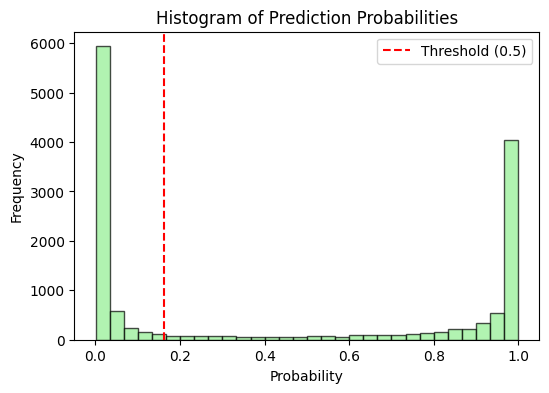

In [10]:
# Create Submission
threshold = np.percentile(labels, 50)
final_labels = ["fake" if p > threshold else "real" for p in labels]

df_sub = pd.DataFrame({"filename": ids, "label": final_labels})

# Sort numerically
df_sub["filename_int"] = df_sub["filename"].astype(int)
df_sub = df_sub.sort_values("filename_int").drop(columns=["filename_int"])

df_sub.to_csv("submission.csv", index=False)
print("Saved submission.csv")
print(df_sub.head())

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.hist(labels, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold (0.5)')
plt.title("Histogram of Prediction Probabilities")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.legend()
plt.show()